In [1]:
import pickle

pkl_dosya_yolu = "/home/uynk/Belgeler/Analyze_Projects/AliBaba_GenAI_Dataset/dataframes.pkl"

# Dosyayı 'rb' (Read Binary - İkili Okuma) formatında açıp içeriğini yüklüyoruz
with open(pkl_dosya_yolu, 'rb') as dosya:
    dataframes = pickle.load(dosya)

## **<span style="color:orange">Analysis</span>** 

### **<span style="color:orange">1. Feature Engineering </span>** 

**Yük dengeleme(Load Balancer) zafiyet analizi**: Düşük kapasite ile çalışan podlara, sistemde işlem hacminin yoğun olduğu zamanlarda daha çok iş verilmesi. İş yükü dengelenmesi analizi.
**Bulut Maliyet Optimizasyonu**: Belirli boş zamanlarda düşük kapasite ile çalışan podların çalışması. Gerekli durumlarda kapatılıp kapatılamayacağının analizi.

In [4]:
import pandas as pd

# Dosya listemiz
dosya_listesi = ["pod_gpu_duty_cycle_anon.csv",
                 "pod_memory_util_anon.csv",
                 "queue_rt_raw_anon.csv",
                 "model_predict_data_anon.csv",
                 "pipeline_inference_data_anon.csv"]

def get_global_time_range(datas):
    tüm_minler = []
    tüm_maxlar = []
    
    for file in datas:
        data = dataframes[file]
        
        tüm_minler.append(data["real_time_CST"].min())
        tüm_maxlar.append(data["real_time_CST"].max())
    
    global_en_erken = min(tüm_minler)
    global_en_gec = max(tüm_maxlar)
    
    print("4 Veri Setinin Genel Zaman Çerçevesi:")
    print(f"Başlangıç Zamanı (En Düşük): {global_en_erken}")
    print(f"Bitiş Zamanı (En Yüksek)   : {global_en_gec}")
    
    return global_en_erken, global_en_gec

en_dusuk_zaman, en_yuksek_zaman = get_global_time_range(dosya_listesi)



def get_common_ips(file_names):
    ip_sets = []
    
    for file in file_names:
        unique_ips = set(dataframes[file]["container_ip"].unique())
        
        ip_sets.append(unique_ips)
        print(f"✔️ {file} tablosunda {len(unique_ips)} adet benzersiz pod bulundu.")
        
    common_ips = set.intersection(*ip_sets)
    
    print(f"🎯 Her {len(file_names)} tabloda da ORTAK bulunan pod sayısı: {len(common_ips)}")
    
    return common_ips

ortak_podlar = get_common_ips(dosya_listesi)




def combine_data_by_minute_event(datas, dataframes_dict, common_ips):
    # En uç sınırları içeren zaman omurgasını oluşturuyoruz
    time_series = pd.date_range(start=en_dusuk_zaman, end=en_yuksek_zaman, freq="1min")
    df_real_time_CST = pd.DataFrame({'real_time_CST': time_series})
    
    processed_dfs = []
    
    for file in datas:
        df = dataframes_dict[file].copy()
        
        # 1. 130 ortak podu filtrele
        df = df[df["container_ip"].isin(common_ips)]
        
        # 2. Tam senin dediğin gibi: Saniyeleri o dakikanın BAŞLANGICINA (:00) yuvarla ve etiketle
        # Örn: 09:12:05 -> 09:12:00 veya 09:12:40 -> 09:12:00 olur.
        df['real_time_CST'] = pd.to_datetime(df['real_time_CST']).dt.floor('1min')
        
        clean_name = file.replace(".csv", "").replace("_anon", "")
        new_col_name = f"{clean_name}_value"
        df.rename(columns={"value": new_col_name}, inplace=True)
        
        # 3. O DAKİKA İÇİNDEKİ DEĞERLERİ GRUPLAMA
        # Senin mantığında: "09:12:05'teki GPU piki ile 09:12:40'taki predict süresi aynı 09:12:00 satırında buluşsun"
        if "pod_gpu_duty_cycle" in clean_name or "pod_memory_util" in clean_name:
            # Kaynak tüketimlerinde o dakika içindeki EN YÜKSEK (max) saniyeyi yakalıyoruz
            # Böylece 09:12:05'teki o GPU piki satıra tık diye yazılır.
            grouped = df.groupby(['real_time_CST', 'container_ip'])[new_col_name].max().reset_index()
        else:
            # Predict ve Pipeline sürelerinde o dakika biten işlemlerin ortalama/toplam süresini alıyoruz
            grouped = df.groupby(['real_time_CST', 'container_ip'])[new_col_name].mean().reset_index()
            
        processed_dfs.append(grouped)
        print(f"✔️ {file} -> 1 dakikalık havuzlama mantığına göre hazırlandı.")

    # 4. KESİŞİM (INNER JOIN)
    print("\n🔄 4 Veri seti ['real_time_CST', 'container_ip'] kilidiyle birleştiriliyor...")
    new_data = processed_dfs[0]
    
    for next_df in processed_dfs[1:]:
        # how='inner': Sadece senin dediğin gibi 4 veri setinde de o DAKİKADA kaydı olan ortak podlar eşleşir
        new_data = pd.merge(new_data, next_df, on=['real_time_CST', 'container_ip'], how='inner')
        
    # Kronolojik düzenleme
    new_data.sort_values(by=['container_ip', 'real_time_CST'], inplace=True)
    new_data.reset_index(drop=True, inplace=True)
    
    print("✅ Tam istediğin mantıkla çalışan new_data veri seti başarıyla oluşturuldu!")
    return new_data

new_data = combine_data_by_minute_event(dosya_listesi, dataframes, ortak_podlar)
new_data.head()

4 Veri Setinin Genel Zaman Çerçevesi:
Başlangıç Zamanı (En Düşük): 2022-09-11 09:12:00
Bitiş Zamanı (En Yüksek)   : 2022-09-12 08:00:00
✔️ pod_gpu_duty_cycle_anon.csv tablosunda 143 adet benzersiz pod bulundu.
✔️ pod_memory_util_anon.csv tablosunda 208 adet benzersiz pod bulundu.
✔️ queue_rt_raw_anon.csv tablosunda 106 adet benzersiz pod bulundu.
✔️ model_predict_data_anon.csv tablosunda 130 adet benzersiz pod bulundu.
✔️ pipeline_inference_data_anon.csv tablosunda 132 adet benzersiz pod bulundu.
🎯 Her 5 tabloda da ORTAK bulunan pod sayısı: 105
✔️ pod_gpu_duty_cycle_anon.csv -> 1 dakikalık havuzlama mantığına göre hazırlandı.
✔️ pod_memory_util_anon.csv -> 1 dakikalık havuzlama mantığına göre hazırlandı.
✔️ queue_rt_raw_anon.csv -> 1 dakikalık havuzlama mantığına göre hazırlandı.
✔️ model_predict_data_anon.csv -> 1 dakikalık havuzlama mantığına göre hazırlandı.
✔️ pipeline_inference_data_anon.csv -> 1 dakikalık havuzlama mantığına göre hazırlandı.

🔄 4 Veri seti ['real_time_CST', 'cont

,real_time_CST,container_ip,pod_gpu_duty_cycle_value,pod_memory_util_value,queue_rt_raw_value,model_predict_data_value,pipeline_inference_data_value
0,2022-09-11 10:31:00,00800b6d2cabe5b9ce855ec9eab6e9ff,23.933333,0.890142,352.0,38836.0,26696.0
1,2022-09-11 11:00:00,00800b6d2cabe5b9ce855ec9eab6e9ff,26.000000,0.890044,126.0,35989.0,25865.0
2,2022-09-11 11:03:00,00800b6d2cabe5b9ce855ec9eab6e9ff,24.933333,0.893323,301.0,36018.0,25780.0
3,2022-09-11 11:08:00,00800b6d2cabe5b9ce855ec9eab6e9ff,33.000000,0.893361,174.0,36959.0,26871.0
4,2022-09-11 11:23:00,00800b6d2cabe5b9ce855ec9eab6e9ff,6.400000,0.893607,182.0,35584.0,24993.0


Eğer bir spesifik pod türünün bütün veri setlerinde, örneğin 11:26:00-12:27:00 zaman aralığında verileri bulunabilir. O pod, üzerinde bir çok farklı sürecin adımlarını ve verilerini barındırıyor olabilir. O pod üzerinde bir işlem için GPU ya daha yeni model yükleniyor olabilir, kurukta olabilir ya da işlem sürecinin sonu olabilir. Ama özünde hepsi o 1 dk lık zaman diliminde ölçülmüş o pod üzerinde olan olaylardır. O zaman aralığında ortalama kuyrukta bekleme süresi, maksimum GPU ve RAM kullanımı, yine o 1 dk lık zaman aralığında ortalama çıkarım süresi verileri elde edilebilir. Ben bu her veriyi 1 dk lık zaman aralıklarında ayırarak bu zaman aralıklarında 4 veri setinde de eşleşen, değeri olan container_ip leri topluyorum(istek tek bir işleme dair veriler olsun bunlar isterse birden fazla işleme dair veriler olsun beni bağlamaz orası.) Bu 4 veri setinde zaman aralıklarına ve container_ip lerine göre eşleşen verilerin, değişkenlerin türüne göre ortalmasını,min,max değerlerini alıp yeni bir veri seti oluşturdum. 

Merge işleminde inner kullandım. Eğer outher kullansaydım. Daha fazla verim olacaktı ve hep pod için 9:12:00 den 8:00:00 zamanına kadar 1 dk lık zaman aralıklarındaki gözlemler yazılacaktı. Hal böyle olunca herhangi bir container_ip nin herhangi bir zaman dilimindeki gözleminde yalnızca GPU kullanım yüzdesi veya yalnızca model predict süresi gibi gözlemler olabilirdi. Ama inner işleminde Herhangi bir pod hangi zaman diliminde hangi veri setinde ölçümü olursa olsun. tek bir satırda ortalama,min,max gibi yöntemler ile tek bir satıra indirger.

İşin özeti şu örneğin 12:36:00 zaman diliminde .... pod için model_predict, queue_rt, GPU_duty verileri ölçülmüş olabilir. Yine aynı zaman diliminde aynı pod üzerinden başka bir işlem yapılmış olabilir ve yalnızca model_predict süresi ölçülmüş olabilir. Yine aynı zaman diliminde aynı pod için başka bir işlem yapılmış ve pipeline_inference süresi ölçümü yapılmış olaiblir. Kodumuzda inner kullanarak bu faklı işlemlerin aynı zaman dilimi ve pod üzerindeki ortalama,min,max çıkarımları yapılarak o zaman dilimi ve o poda ait tek bir satıra indirgenerek. O pod üzerindeki yük ve kullanım şekli belirlenmeye çalışılmıştır. 

#### **<span style="color:orange"> Outlier detections in New_data </span>** 

In [5]:
features = [
    'pod_gpu_duty_cycle_value', 
    'pod_memory_util_value', 
    'queue_rt_raw_value', 
    'model_predict_data_value', 
    'pipeline_inference_data_value'
]

def count_outliers_iqr(df, columns):
    print("🚨 DEĞİŞKEN BAZLI AYKIRI DEĞER (OUTLIER) RAPORU 🚨")
    print("-" * 55)
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        alt_sinir = Q1 - 1.5 * IQR
        ust_sinir = Q3 + 1.5 * IQR
        
        # Sınırların dışında kalanları filtrele
        outliers = df[(df[col] < alt_sinir) | (df[col] > ust_sinir)]
        outlier_sayisi = len(outliers)
        outlier_orani = (outlier_sayisi / len(df)) * 100
        
        print(f"📌 {col}:")
        print(f"   Üst Sınır Değeri : {ust_sinir:.2f}")
        print(f"   Aykırı Satır Sayısı: {outlier_sayisi} (%{outlier_orani:.2f})\n")

# Fonksiyonu çalıştır
count_outliers_iqr(new_data, features)

🚨 DEĞİŞKEN BAZLI AYKIRI DEĞER (OUTLIER) RAPORU 🚨
-------------------------------------------------------
📌 pod_gpu_duty_cycle_value:
   Üst Sınır Değeri : 46.93
   Aykırı Satır Sayısı: 27 (%1.99)

📌 pod_memory_util_value:
   Üst Sınır Değeri : 1.18
   Aykırı Satır Sayısı: 1 (%0.07)

📌 queue_rt_raw_value:
   Üst Sınır Değeri : 476.00
   Aykırı Satır Sayısı: 48 (%3.54)

📌 model_predict_data_value:
   Üst Sınır Değeri : 62428.50
   Aykırı Satır Sayısı: 249 (%18.36)

📌 pipeline_inference_data_value:
   Üst Sınır Değeri : 42786.00
   Aykırı Satır Sayısı: 7 (%0.52)



#### **<span style="color:orange"> Robust Scaling & PAM Cluster </span>** 

- Önce, aykırı değerlerin ezilmemesi, ancak değişken birimlerinin ölçeklendirimesi için RobustScaler uygulanmalıdır. 

- PAM algoritması, belirlediğim küme sayısı kadar satırı rasgele seçer ve bunları medoid küme lideri kabul eder. Veri setinde geri kalan tüm satırlar, uzaysal olarak kendilerine en yakın Medoid'e atanır. Uzaklık ölçümü için genellikler Manhattan(L1 Normu) ve Öklid(L2 Normu) mesafesi kullanılır. İki veri noktası arasındaki Manhattan mesafesi:

$$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$

- Yer değiştime ve Maliyet: Algoritma acaba seçtiğim bu lider yerine sıradan bir satırı lider yapsam küme içerisindeki toplam mesafe azalır mı? diye sorar. Bir Medoid ile medoid olmayan bir nokta yer değiştirir. 

- Yakınsama: Yer değiştirme işlemi toplam maliyeti düşürüyorsa yeni lider o olur.

In [6]:
# --- SİSTEM YAPILANDIRMASI VE KÜTÜPHANELER ---
import pandas as pd
import numpy as np
import warnings

# Pyclustering kütüphanesi (2022) modern NumPy ile çökmesin diye uyumluluk yaması:
np.warnings = warnings 

from sklearn.preprocessing import RobustScaler
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.cluster.center_initializer import kmeans_plusplus_initializer
# ----------------------------------------------
# pyclustering kütüphanesi içerisinde numpy.warning adında bir komut bulunduğu için ve numpy 1.26.4 sürümünde de artık bu komutu kendi içerisinde barndırmadığı için biz de pyclustering
# warning komutunu bulabilmesi için koda yama yaparak sanki numpy içerisinde warning varmış gibi gösterildi.



# 1. Analiz edilecek 5 özelliği seçiyoruz
features = [
    'pod_gpu_duty_cycle_value', 
    'pod_memory_util_value', 
    'queue_rt_raw_value', 
    'model_predict_data_value', 
    'pipeline_inference_data_value'
]
X = new_data[features]

# 2. Aykırı değerlere dirençli ölçeklendirme (RobustScaler)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X).tolist() 

# 3. Lider Podları (Medoid) Seçme ve PAM Algoritmasını Çalıştırma
print("Algoritma çalışıyor, 3 ana darboğaz/lider pod aranıyor...")

initial_medoids = kmeans_plusplus_initializer(X_scaled, 3, random_state=42).initialize(return_index=True) # ilk lider rasgele seçilir. ikincisi ilkine en uzak olanlardan seçer. üçüncüsü de ilk ikisine en uzak olanlardan seçilir. 
print(initial_medoids) # seçilen 3 tane liderler. 

pam = kmedoids(X_scaled, initial_medoids)  
pam.process() # Diğer tüm podların bu 3 lidere uzaklıkları hesaplanır. Gerekirse liderler değiştirilerek kümeleri en optimal (en az hata veren) hale getirene kadar döngüye girer. 

# 4. Kümeleri Veri Setine İşleme
clusters = pam.get_clusters()

# 4. Kümeleri Veri Setine İşleme
clusters = pam.get_clusters()

# Önce veri setine 'Cluster' adında boş (-1 ile dolu) bir sütun açıyoruz
new_data['Cluster'] = -1 

# enumerate ile hem kümenin numarasını (0, 1, 2) hem de o kümeye ait satır listesini aynı anda alıyoruz
for cluster_id, row_indices in enumerate(clusters):
    # iloc ile o satırlara gidip, 'Cluster' sütununa ait oldukları küme numarasını (cluster_id) yazdırıyoruz
    new_data.iloc[row_indices, new_data.columns.get_loc('Cluster')] = cluster_id

print("✅ PAM algoritması başarıyla çalıştı ve veri seti kümelendi!")

# Küme dağılımlarını ekranda net bir şekilde görelim
display(new_data['Cluster'].value_counts())
    

Algoritma çalışıyor, 3 ana darboğaz/lider pod aranıyor...
[1309, 1004, 185]
✅ PAM algoritması başarıyla çalıştı ve veri seti kümelendi!


Cluster
2    924
0    243
1    189
Name: count, dtype: int64

In [7]:
# Her bir kümenin o 5 metrikteki ortalama değerlerini hesapla 
cluster_profiles = new_data.groupby('Cluster')[features].mean()
display(cluster_profiles.T) 

Cluster,0,1,2
pod_gpu_duty_cycle_value,26.539672,12.606702,25.360299
pod_memory_util_value,0.670654,0.661335,0.662288
queue_rt_raw_value,261.013374,248.427249,228.142587
model_predict_data_value,63616.514403,13578.825397,37554.477814
pipeline_inference_data_value,24245.953018,10911.558642,23486.470869


- 🔴 **Küme 0 Darboğaz (Ağır Yük Altında Ezilen Podlar):** Bu küme, sistemin sınırlarını zorlayan kapasite aşımı(overload) yaşayan podları temsil edebilir. Ağır işlem hacimlerine bağlı olarak, kuyruk bekleme süresi ve gecikmelerin en yoğun yaşandığı zaman aralıklarını ve container_ip leri barındırıyor olabilir.
- 🔵 **Küme 1 Atıl Kapasite (Rölantide Bekleyen Podlar):** Bu küme, kaynkaları rezerve edilmiş olmasına rağmen yeterli iş yükü almayan podlarıtemsil ediyor olabilir. Düşük işlem hacmi ve GPU kullanımısergiliyor olabilirler.
- 🟢 **Küme 2 İdeal Performans (Sağlıklı İşçi Podlar):** Bu küme, bulut altyapısında hedeflenen optimum çalışma durumunu yansıtır. Kapasitelerine uygun, dengeli işlem yükleri alıyor olabilirler. Bu sayede GPU kaynaklarını verimli kullanıyor olabilirler. 


#### **<span style="color:orange"> Zaman Çizelgesinde Kümelere Göre İşlem Sayıları Grafiği (EDA) </span>** 

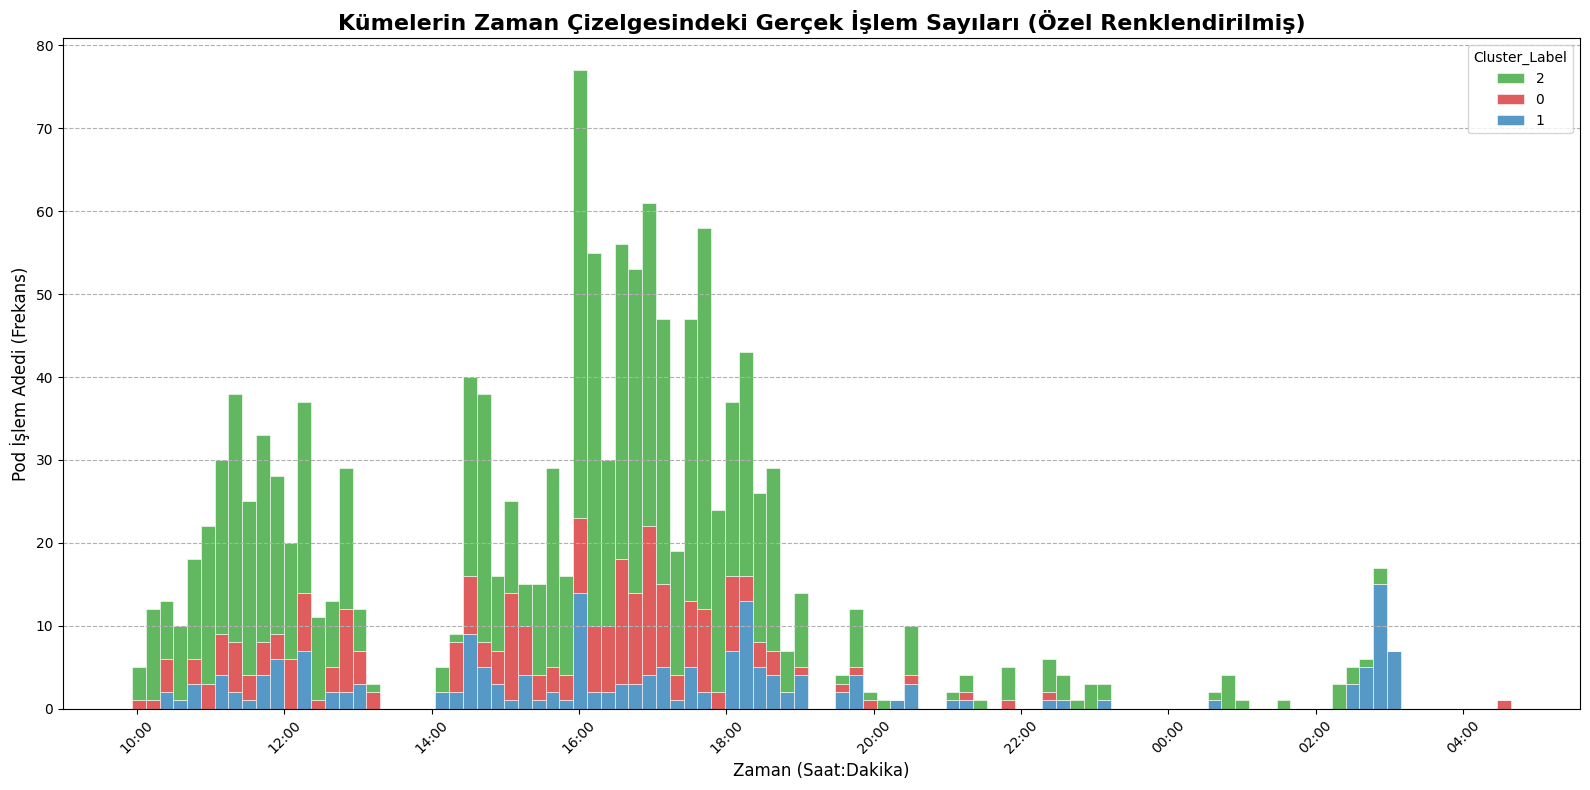

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. Veri formatı hazırlığı (Öncekiyle aynı)
new_data["Cluster_Label"] = new_data["Cluster"].astype(str)

# 2. ÖZEL RENK PALETİ SÖZLÜĞÜ (İşte sihir burada)
# Çok parlak/göz yoran renkler olmaması için matplotlib'in profesyonel "tab:" renklerini kullanıyoruz
custom_colors = {
    "0": "tab:red",    # Küme 0 (Darboğaz) -> Kırmızı
    "1": "tab:blue",   # Küme 1 (Atıl)     -> Mavi
    "2": "tab:green"   # Küme 2 (Sağlıklı) -> Yeşil
}

plt.figure(figsize=(16, 8))

# 3. Grafiği Çizdirme
ax = sns.histplot(
    data=new_data, 
    x="real_time_CST", 
    hue="Cluster_Label", 
    multiple="stack",   
    bins=100,            
    palette=custom_colors, 
    edgecolor="white",
    linewidth=0.4
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.title("Kümelerin Zaman Çizelgesindeki Gerçek İşlem Sayıları (Özel Renklendirilmiş)", fontsize=16, fontweight='bold')
plt.xlabel("Zaman (Saat:Dakika)", fontsize=12)
plt.ylabel("Pod İşlem Adedi (Frekans)", fontsize=12)

plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show() 

**18 saatlik zaman aralığındaki grafiğin yorumu:** Mavi satırlara odaklancak olursak işlem hacminin yoğun olduğu saatlerde bazı podların atıl halde kalması problemidir gözümüze çarpabilir. İşlem hacminin yoğun olduğu saatlerde Internal Load Balancer'ın optimize edilmesi gerekebilir yorumu yapılabilir. 

- Sitemin mevcut yük yönlendirme algoritması değiştirilebilir. Kubernetes ve Internal Load Balancer, yeni bir işi göndermeden önce queue_rt_raw_value ve GPU kullanım metriklerine bakması gerekebilir. `Bekelenen sonuç:` Kırmızı podlara giden işler, o saatte altta yatan mavi podlara kaydırılmalı. Böylece kırmızı katmanın yeile dönmesi sağlanabilir. 

- Gece 02.30 sularında o anlamsız bekleyen mavi kuleyi yaratan arka plan işlemleri tespit edilip optimize edilmelidir. Kullanıcı trafiği olmayan saatlerde atıl bekleyen podların kapatılıp kapatılamayacağına bakılabilir. 